![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/SparkOCRDocumentLayoutAnalyzer.ipynb)

# Document Layout Analysis

This notebook covers two document layout models in Spark OCR:

- **`DocumentLayoutAnalyzer`**: `publaynet_dit_base_mrcnn_jsl`
- **`ImageLayoutDetector`**: OpenVINO `image_layout_detector_ov` and ONNX `image_layout_detector_onnx`

## Install the spark-ocr Python package

Specify the path to `spark-ocr-assembly-[version].jar` or provide your `secret`.

In [1]:
from pyspark.sql import SparkSession
from sparkocr import start
import os

secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

if license:
    os.environ['SPARK_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.4.1
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2

:: loading settings :: url = jar:file:/usr/local/lib/python3.11/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp-gpu_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b51da229-035e-4c15-8da0-921264573cb7;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp-gpu_2.12;6.4.2 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	fou

In [2]:
from pyspark.ml import PipelineModel
import pyspark.sql.functions as F

from sparkocr import start
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *
from sparkocr.metrics import score

## Read Image as Spark Dataframe

In [3]:
image_path = "./data/layout_paper.png"
df = spark.read.format("binaryFile").load(image_path)

df.columns

['path', 'modificationTime', 'length', 'content']

## Load the DocumentLayoutAnalyzer Pipeline

In [4]:
binary_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setImageType(ImageType.TYPE_3BYTE_BGR)

dit_layout = DocumentLayoutAnalyzer.pretrained("publaynet_dit_base_mrcnn_jsl", "en", "clinical/ocr") \
    .setInputCol("image") \
    .setOutputCol("regions") \
    .setScoreThreshold(0.45)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("regions") \
    .setOutputCol("image_with_layout_regions") \
    .setRectColor(Color.green) \
    .setDisplayMetadata(True)

pipeline = PipelineModel(stages=[
    binary_to_image,
    dit_layout,
    draw_regions
])

publaynet_dit_base_mrcnn_jsl download started this may take some time.
Approximate size to download 401.2 MB
publaynet_dit_base_mrcnn_jsl download started this may take some time.
Approximate size to download 401.2 MB
Download done! Loading the resource.


In [5]:
result = pipeline.transform(df).cache()
result.columns

['image',
 'path',
 'modificationTime',
 'length',
 'pagenum',
 'image_dims',
 'regions',
 'image_with_layout_regions',
 'exception']


    Image #0:
    Origin: file:/workspace/visual-nlp-workshop/jupyter/data/layout_paper.png
    Resolution: 143 dpi
    Width: 1120 px
    Height: 1434 px
    Mode: 5
    Number of channels: 3


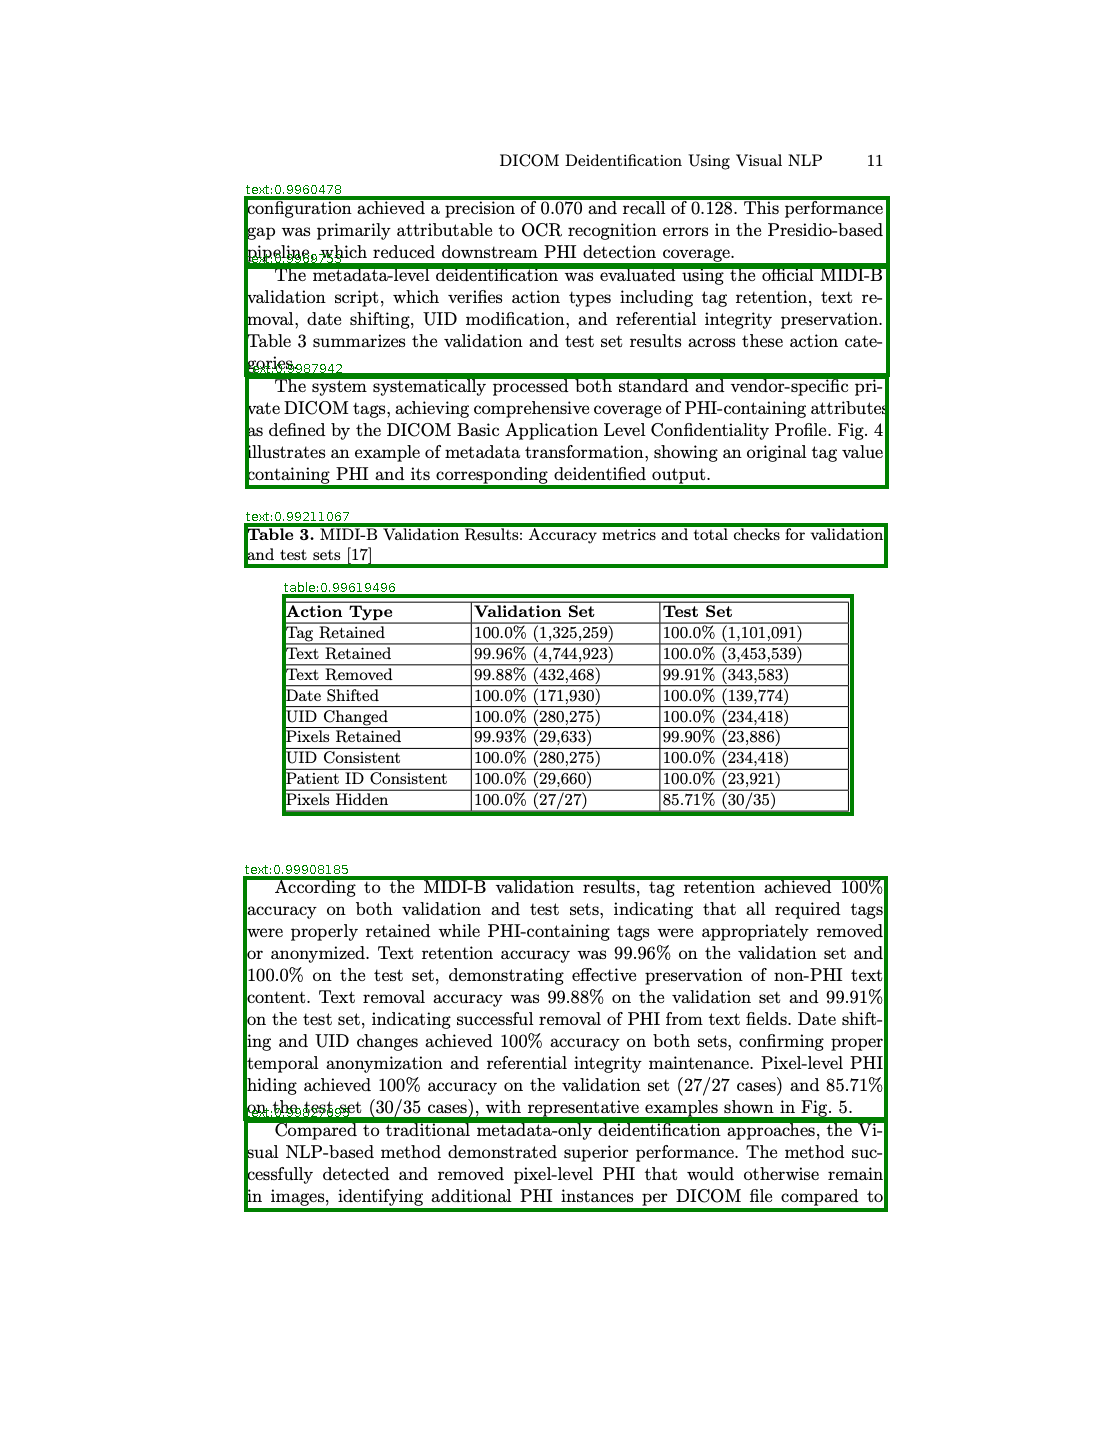

In [6]:
display_images(df=result, field="image_with_layout_regions", limit=1, width=200, show_meta=True)

## ImageLayoutDetector

> **Version requirement:** `ImageLayoutDetector` only works with **Spark OCR 6.4.2**.

`ImageLayoutDetector` provides two pretrained inference backends:

- **`image_layout_detector_ov`** — optimised for OpenVINO CPU session.
- **`image_layout_detector_onnx`** — runs on CPU and GPU via an ONNX session.

Key parameters:

- **`setIouThreshold`** — IoU threshold for NMS post-processing; a value between 0 and 1.
- **`setThresholdMap`** — a dictionary mapping a text label to a float between 0 and 1. A label passed here overrides the default score threshold.
- **`setPredictionLabels`** — the labels to predict for.

In [7]:
allowed_labels = [
    "Caption", "Footnote", "Formula", "List-item", "Page-footer",
    "Page-header", "Picture", "Section-header", "Table", "Text", "Title"
]

## ImageLayoutDetector OpenVINO Inference

In [8]:
binary_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setImageType(ImageType.TYPE_3BYTE_BGR)

prediction_class = {"Text": 0.10, 'Section-header': 0.20, "Table": 0.60 }

layout_detector = ImageLayoutDetector.pretrained("image_layout_detector_ov", "en", "clinical/ocr") \
    .setInputCol("image") \
    .setOutputCol("region") \
    .setScoreThreshold(0.6) \
    .setIouThreshold(0.1) \
    .setThresholdMap(prediction_class)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("region") \
    .setOutputCol("image_with_layout_regions") \
    .setFilledRect(False) \
    .setDisplayMetadata(True) \
    .setRectColor(Color.green)

pipeline = PipelineModel(stages=[
    binary_to_image,
    layout_detector,
    draw_regions
])

image_layout_detector_ov download started this may take some time.
Approximate size to download 31.1 MB
image_layout_detector_ov download started this may take some time.
Approximate size to download 31.1 MB
Download done! Loading the resource.


In [9]:
result = pipeline.transform(df).cache()
result.columns

['image',
 'path',
 'modificationTime',
 'length',
 'pagenum',
 'image_dims',
 'region',
 'image_with_layout_regions',
 'exception']


    Image #0:
    Origin: file:/workspace/visual-nlp-workshop/jupyter/data/layout_paper.png
    Resolution: 143 dpi
    Width: 1120 px
    Height: 1434 px
    Mode: 5
    Number of channels: 3


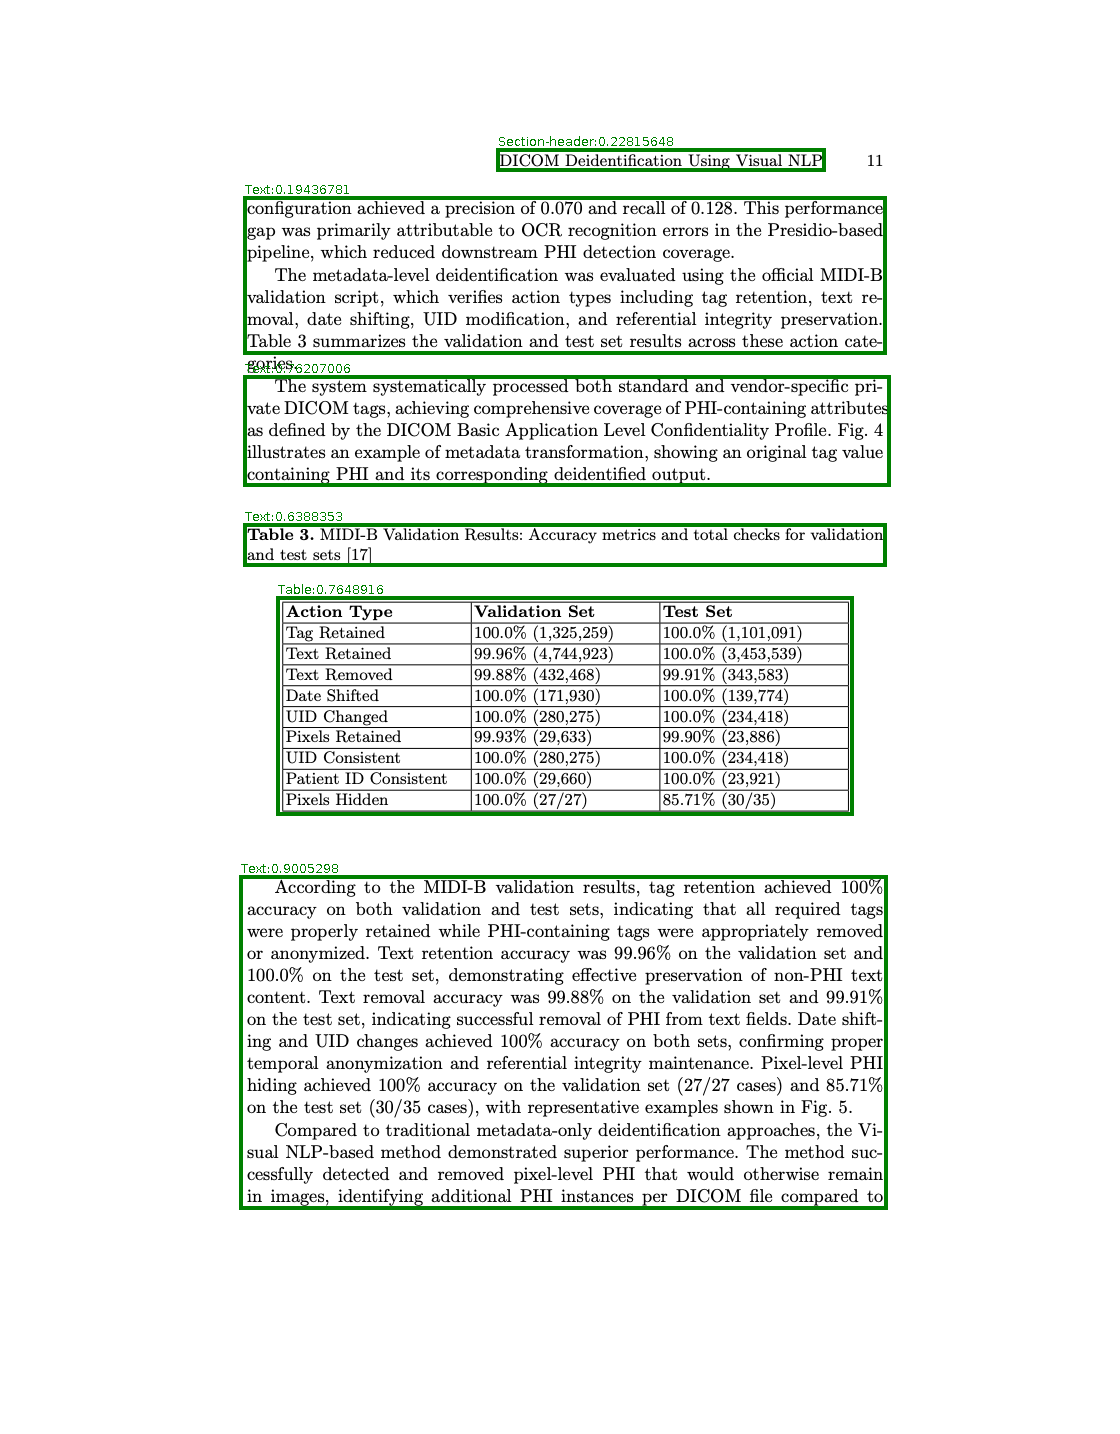

In [10]:
display_images(df=result, field="image_with_layout_regions", limit=1, width=200, show_meta=True)

## ImageLayoutDetector ONNX Inference

In [11]:
binary_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setImageType(ImageType.TYPE_3BYTE_BGR)

prediction_class = {"Text": 0.10, 'Section-header': 0.20, "Table": 0.60 }

layout_detector = ImageLayoutDetector.pretrained("image_layout_detector_onnx", "en", "clinical/ocr") \
    .setInputCol("image") \
    .setOutputCol("region") \
    .setIouThreshold(0.1) \
    .setThresholdMap(prediction_class) \
    .setUseGPU(False)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("region") \
    .setOutputCol("image_with_layout_regions") \
    .setFilledRect(False) \
    .setDisplayMetadata(True) \
    .setRectColor(Color.green)

pipeline = PipelineModel(stages=[
    binary_to_image,
    layout_detector,
    draw_regions
])

image_layout_detector_onnx download started this may take some time.
Approximate size to download 31.1 MB
image_layout_detector_onnx download started this may take some time.
Approximate size to download 31.1 MB
Download done! Loading the resource.


In [12]:
result = pipeline.transform(df).cache()
result.columns

['image',
 'path',
 'modificationTime',
 'length',
 'pagenum',
 'image_dims',
 'region',
 'image_with_layout_regions',
 'exception']


    Image #0:
    Origin: file:/workspace/visual-nlp-workshop/jupyter/data/layout_paper.png
    Resolution: 143 dpi
    Width: 1120 px
    Height: 1434 px
    Mode: 5
    Number of channels: 3


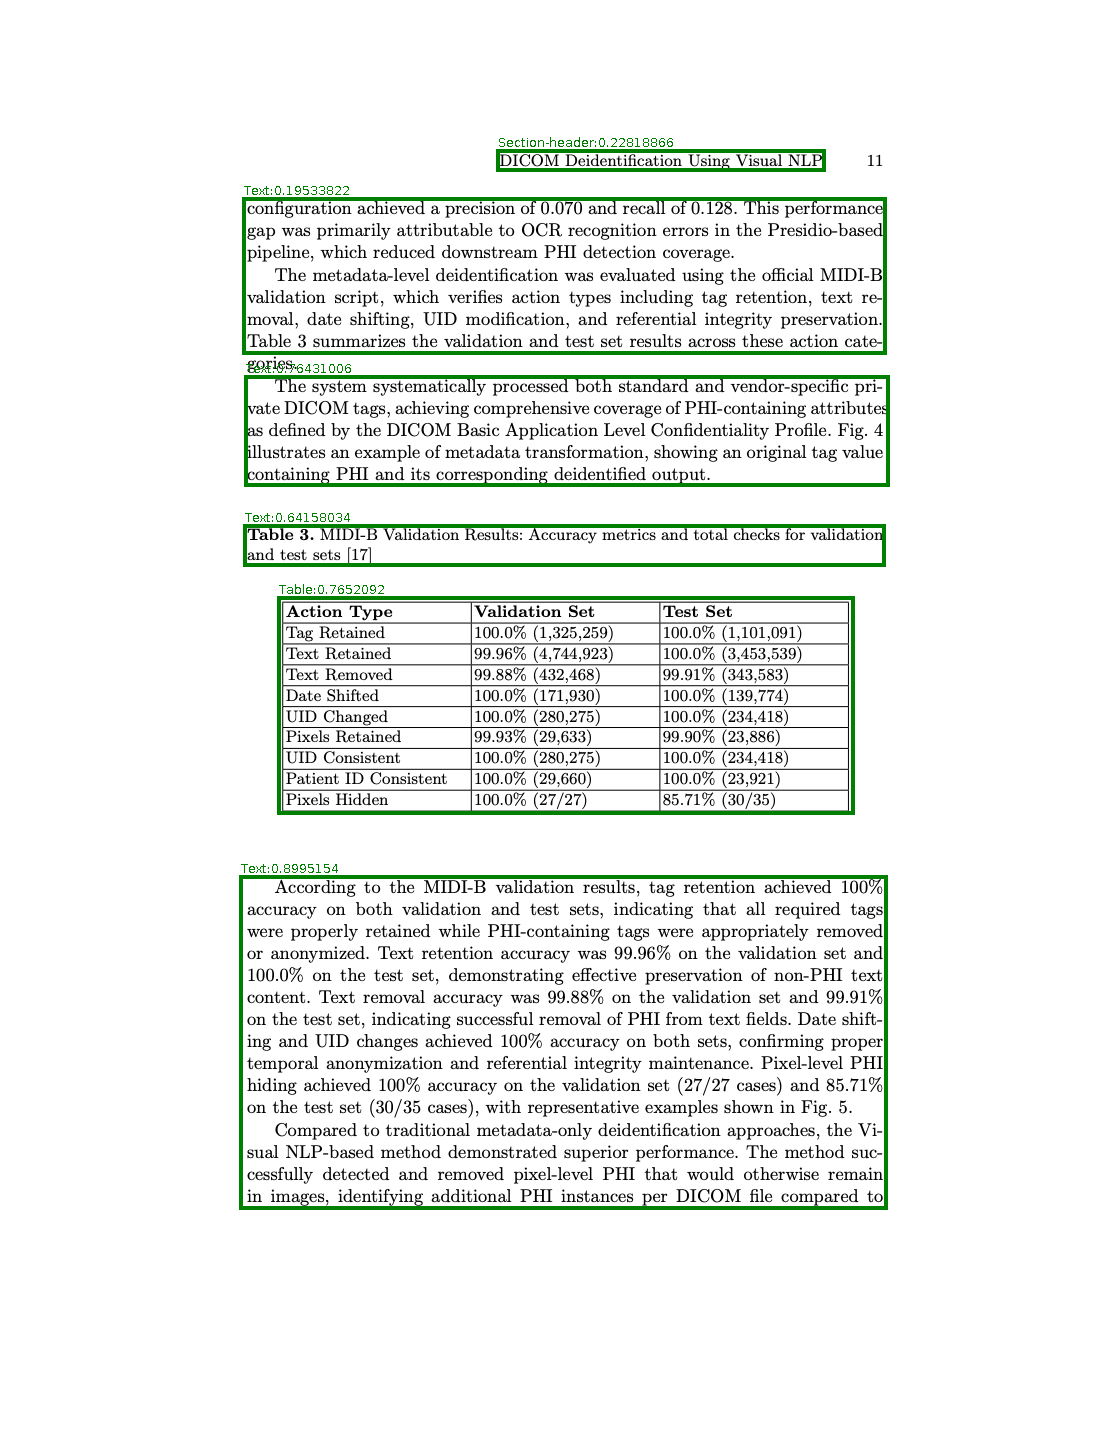

In [13]:
display_images(df=result, field="image_with_layout_regions", limit=1, width=200, show_meta=True)